# **Respiratory Rate Data Cleaning - Week 0, Assignment 2**

Contributers - Tyler Baksh , Kaylah Leigertwood-Ollivierre , Mya Symister, Sariana Ramoutar, Zhanna McDonald , Sekou Ruddock

In [ ]:
# Confirm Python version >= 3.10
import sys
print(f'Python version: {sys.version}')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# Import necessary libraries:

import pandas as pd #data handling
import numpy as np # numerical operations (NaNs, Arrays)
import matplotlib.pyplot as plt # visualisation

print('Libraries imported successfully!')

Libraries imported successfully!


In [ ]:
# Load dataset and display shape & column names
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df_raw = pd.read_csv(FILE_PATH)

# Display dataset information
print('Dataset successfully loaded!')
print(f'Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns') #dataset size check
print(f'Columns: {list(df_raw.columns)}') #confirm structure

FileNotFoundError: [Errno 2] No such file or directory: 'EmergencyTriageDataset_Reduced_Dirty.csv'

In [ ]:
# ── Respiratory Rate (RR) Cleaning ──────────────────────────────────


COLUMN = 'RR'   # RR = Respiratory Rate (breaths per minute)
VALID_MIN = 5            # clinically plausible min RR
VALID_MAX = 60          # clinically plausible max RR

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df_raw[COLUMN].unique()[:15]}") # quick scan of raw values
print(f"Dtype: {df_raw[COLUMN].dtype}") # check data type
print()

# Step 1: Convert to numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce') # force numberic, invalid -> NaN

# kept as float because imputation (mean/median) produces decimals and preserves consistency
print(f"After type conversion — NaNs: {df_raw[COLUMN].isnull().sum()}")
print(df_raw[COLUMN].describe()) #summary stats after conversion

=== Cleaning: RR ===


NameError: name 'df_raw' is not defined

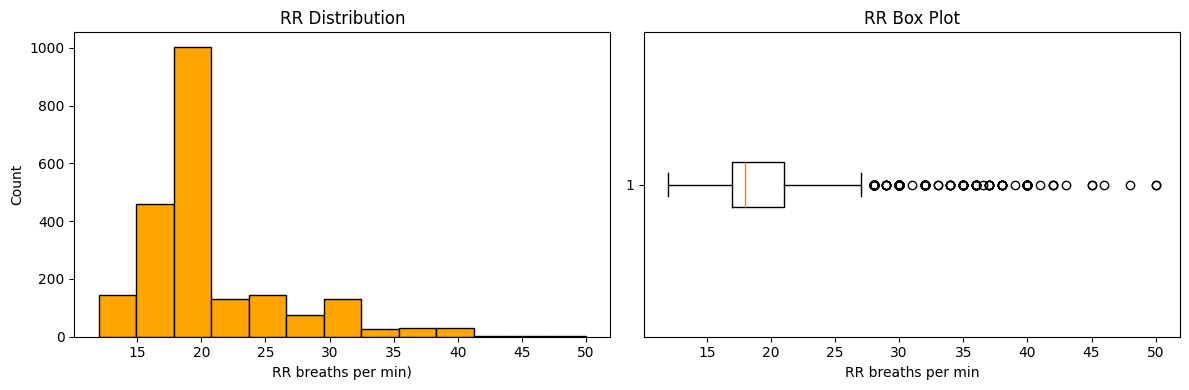

Plot saved as rr_distribution.png


In [ ]:
# ── Step 1: Visualise BEFORE Cleaning ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='orange') #distribution shape
axes[0].set_xlabel('RR breaths per min')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution')

axes[1].boxplot(df_raw['RR'].dropna(), vert=False) # outlier visual check
axes[1].set_xlabel('RR breaths per min')
axes[1].set_title('RR Box Plot')

plt.tight_layout()
plt.savefig('rr_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as rr_distribution.png")

Out-of-range values: 0
Out-of-range values: 0

After cleaning:
count    2205.000000
mean       20.239683
std         5.718026
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64
NaNs remaining: 0


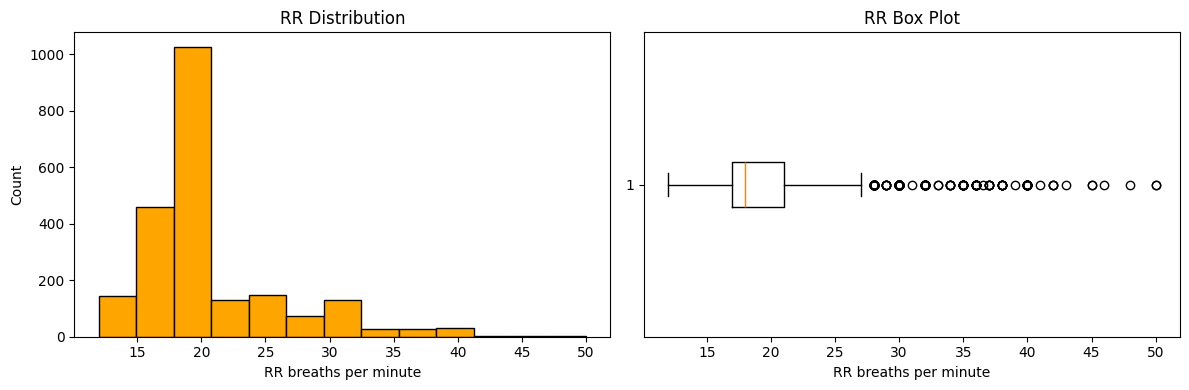

Plot saved as rr_distribution.png


In [ ]:
# ── Step 2: Range filter ──────────────────────────────────
invalid = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)] # detect invalid clinical values
print(f"Out-of-range values: {len(invalid)}")

# note: no true outliers found ( all values clinically valid ~12-50)
df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan


#── Step 3: Impute ──────────────────────────────────

# median chosen because data is right-skewed (high RR values pull mean upward)
# mean (~20.24) would be biased; median (~18) is more robust

impute_value = df_raw[COLUMN].median()
(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)
print(f"Out-of-range values: {len(invalid)}")

df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan

#── Step 3: Impute ───────────────────────────────────
impute_value = df_raw[COLUMN].median()
df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df_raw[COLUMN].describe()) # final distribution check
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}")# confirm no missing values left
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['RR'].dropna(), bins=13, edgecolor='black', color='orange')
axes[0].set_xlabel('RR breaths per minute')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution')

axes[1].boxplot(df_raw['RR'].dropna(), vert=False)
axes[1].set_xlabel('RR breaths per minute')
axes[1].set_title('RR Box Plot')

plt.tight_layout()
plt.savefig('rr_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as rr_distribution.png")
